In [ ]:
import random
import shutil
from pathlib import Path


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from utils import *
from data_fetch import download_dataset

In [ ]:

download_dataset(
    "harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset",
    "./data",
    force_download=False
)


Dataset URL: https://www.kaggle.com/datasets/harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset
Done! Dataset location: /content/Sentinel-1-Oil-Spill-Detection/data
Folders found: ['data', 'metadata']


In [ ]:
# Variables alignées avec le repo
ROOT_DIR = Path("./data")
DATA_DIR = ROOT_DIR / "data"
SEED = 42

# Fixer la reproductibilité pour ton EDA
random.seed(SEED)
np.random.seed(SEED)

print("ROOT_DIR:", ROOT_DIR.resolve())
print("DATA_DIR exists:", DATA_DIR.exists())
print("Classes:", [d.name for d in DATA_DIR.iterdir() if d.is_dir()])

ROOT_DIR: /content/Sentinel-1-Oil-Spill-Detection/data
DATA_DIR exists: True
Classes: ['S1SAR_UnBalanced_400by400_Class_1', 'Samples', 'S1SAR_UnBalanced_400by400_Class_0']


Vérification du nombre d'images par classe

In [15]:
class_counts = {}

for class_dir in DATA_DIR.iterdir():
    if class_dir.is_dir() and "Class" in class_dir.name:
        total = sum(1 for _ in class_dir.rglob("*.jpg"))
        class_counts[class_dir.name] = total

class_counts


{'S1SAR_UnBalanced_400by400_Class_1': 1905,
 'S1SAR_UnBalanced_400by400_Class_0': 3725}

Distribution des intensités (global) par classe

Objectif : confirmer et quantifier le signal “oil = plus sombre”, mais aussi voir l’overlap.

On va échantillonner un nombre fixe d’images par classe (reproductible via SEED) pour ne pas exploser le temps.

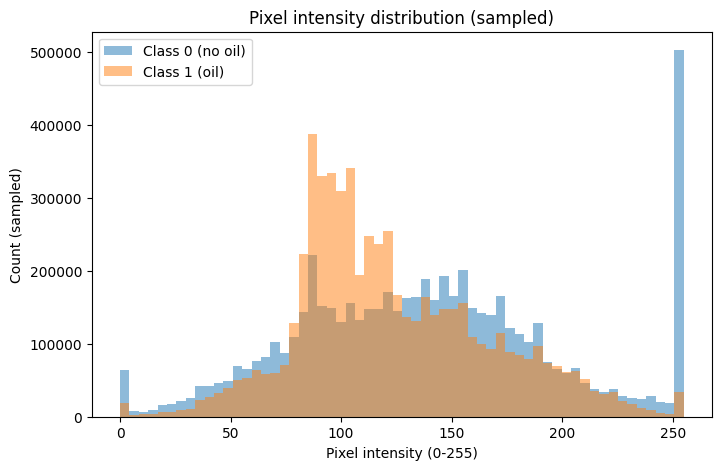

Mean/Std class0: 139.0201545 59.69853222620127
Mean/Std class1: 122.7578465 43.97843872303529


In [ ]:
def sample_image_paths(class_dir, n=300):
    paths = sorted([p for p in class_dir.rglob("*.jpg")])
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(paths), size=min(n, len(paths)), replace=False)
    return [paths[i] for i in idx]

def collect_pixels(image_paths, max_pixels_per_image=20000):
    rng = np.random.default_rng(SEED)
    all_pixels = []
    for p in image_paths:
        arr = np.array(Image.open(p).convert("L"), dtype=np.uint8).reshape(-1)
        # sous-échantillonnage des pixels pour accélérer
        k = min(max_pixels_per_image, arr.size)
        sel = rng.choice(arr.size, size=k, replace=False)
        all_pixels.append(arr[sel])
    return np.concatenate(all_pixels)

class0_dir = DATA_DIR / "S1SAR_UnBalanced_400by400_Class_0"
class1_dir = DATA_DIR / "S1SAR_UnBalanced_400by400_Class_1"

paths0 = sample_image_paths(class0_dir, n=300)
paths1 = sample_image_paths(class1_dir, n=300)

pix0 = collect_pixels(paths0)
pix1 = collect_pixels(paths1)

plt.figure(figsize=(8,5))
plt.hist(pix0, bins=60, alpha=0.5, label="Class 0 (no oil)")
plt.hist(pix1, bins=60, alpha=0.5, label="Class 1 (oil)")
plt.title("Pixel intensity distribution (sampled)")
plt.xlabel("Pixel intensity (0-255)")
plt.ylabel("Count (sampled)")
plt.legend()
plt.show()

print("Mean/Std class0:", float(pix0.mean()), float(pix0.std()))
print("Mean/Std class1:", float(pix1.mean()), float(pix1.std()))

Oil (class 1) est plus sombre en moyenne
 cohérent physiquement (film d’huile lisse la surface → moins de rétrodiffusion)

 Class 0 a une variance plus élevée
 plus de texture / mer agitée / structures

 Gros pic à 255 côté class 0

Ça peut correspondre à : saturation, artefact, forte rétrodiffusion ou compression JPEG

Analyse image-level (pas pixel-level)

Maintenant on ne regarde plus tous les pixels mélangés. On regarde chaque image comme une unité.

On va calculer pour chaque image :

mean

std

proportion de pixels saturés (= 255)

In [ ]:


def image_stats(img_path):
    arr = np.array(Image.open(img_path).convert("L"), dtype=np.uint8)
    return {
        "path": str(img_path),
        "mean": float(arr.mean()),
        "std": float(arr.std()),
        "sat255_ratio": float((arr == 255).mean()),
        "sat0_ratio": float((arr == 0).mean()),
    }

def build_stats_df(class_dir, label, n=600):
    paths = sample_image_paths(class_dir, n=n)
    rows = [image_stats(p) for p in paths]
    df = pd.DataFrame(rows)
    df["label"] = label
    return df

stats0 = build_stats_df(class0_dir, label=0, n=600)
stats1 = build_stats_df(class1_dir, label=1, n=600)
stats = pd.concat([stats0, stats1], ignore_index=True)

stats.groupby("label")[["mean","std","sat255_ratio","sat0_ratio"]].agg(["mean","median","std"]).round(4)

mean                         std                   sat255_ratio  \
           mean    median      std     mean   median      std         mean   
label                                                                        
0      135.6517  138.2695  47.6553  28.0719  20.8060  22.7650       0.0727   
1      120.6338  113.2271  39.6240  14.4899  10.4958  13.4979       0.0078   

                     sat0_ratio                 
      median     std       mean median     std  
label                                           
0        0.0  0.1693     0.0088    0.0  0.0498  
1        0.0  0.0489     0.0021    0.0  0.0097

Résultats image-level
Moyenne d’intensité

Class 0 : mean ≈ 135.7

Class 1 : mean ≈ 120.6
Confirmation : oil plus sombre.

Écart-type (texture globale)

Class 0 : std ≈ 28.1

Class 1 : std ≈ 14.5

La différence de variance est énorme ce qui voudrait dire que:

Oil = surface plus homogène
 , No oil = plus texturé / bruité

Proportion de pixels saturés à 255

Class 0 : mean ≈ 7.3%

Class 1 : mean ≈ 0.78%

Les images “no oil” ont en moyenne 10× plus de pixels saturés ce qui pourrait expliquer le pic à 255.

Pixels à 0

Faible dans les deux classes.
Donc le problème est surtout du côté hautes intensités.

Conclusion provisoire

Il y a 3 signaux très forts :

Mean plus faible pour oil

Std beaucoup plus faible pour oil

Saturation à 255 beaucoup plus fréquente en class 0



Détéction des outliers

In [18]:
# Top outliers par saturation 255
top_sat = stats.sort_values("sat255_ratio", ascending=False).head(10)

# Images très homogènes (std très faible)
low_std = stats.sort_values("std", ascending=True).head(10)

# Images très texturées (std très élevé)
high_std = stats.sort_values("std", ascending=False).head(10)

print("=== Top 10 saturation 255 ===")
display(top_sat[["path","label","sat255_ratio","mean","std"]])

print("\n=== Top 10 low std (very smooth) ===")
display(low_std[["path","label","std","mean","sat255_ratio"]])

print("\n=== Top 10 high std (very textured) ===")
display(high_std[["path","label","std","mean","sat255_ratio"]])

=== Top 10 saturation 255 ===


,path,label,sat255_ratio,mean,std
63,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,0.921687,245.195206,36.370588
521,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,0.872637,237.335156,54.823338
292,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,0.858556,228.270263,70.622923
428,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,0.834044,230.161831,61.424874
136,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,0.820688,226.157675,68.153098
375,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,0.810756,218.519706,80.110797
109,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,0.810419,217.038369,87.045123
98,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,0.789975,237.630775,34.774498
82,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,0.770537,229.141731,52.077280
161,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,0.738513,222.698762,55.468245



=== Top 10 low std (very smooth) ===


,path,label,std,mean,sat255_ratio
318,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,0.000000,142.000000,0.0
449,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,1.683713,102.788919,0.0
74,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,1.722826,93.526619,0.0
312,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,1.757034,89.347413,0.0
590,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,1.822491,116.820763,0.0
254,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,1.830559,85.439238,0.0
946,data/data/S1SAR_UnBalanced_400by400_Class_1/1/...,1,1.905313,84.992731,0.0
133,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,1.944891,110.468613,0.0
328,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,1.964938,112.157206,0.0
454,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,1.966684,87.360256,0.0



=== Top 10 high std (very textured) ===


,path,label,std,mean,sat255_ratio
507,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,116.779540,106.395488,0.348194
17,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,116.582973,144.729769,0.522144
286,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,111.285559,97.642331,0.306812
553,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,107.583096,161.236775,0.558400
46,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,104.587909,161.004256,0.523950
278,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,102.865096,168.083019,0.577975
528,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,101.351087,185.310612,0.649750
808,data/data/S1SAR_UnBalanced_400by400_Class_1/1/...,1,98.788942,143.804438,0.411019
397,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,95.912357,182.470750,0.626956
125,data/data/S1SAR_UnBalanced_400by400_Class_0/0/...,0,95.278797,181.774856,0.619219


L’analyse au niveau des images met en évidence des différences structurelles marquées entre les deux classes. Les images contenant des nappes d’huile (classe 1) présentent une intensité moyenne plus faible et, surtout, un écart-type significativement plus bas que les images sans huile (classe 0). Cela indique que les nappes d’huile apparaissent plus homogènes en imagerie SAR. Ce résultat est cohérent d’un point de vue physique : la présence d’huile amortit les petites vagues en surface, réduisant la variabilité du signal radar et produisant des zones plus lisses et moins texturées.

Par ailleurs, la proportion de pixels saturés (intensité = 255) est nettement plus élevée dans la classe 0, atteignant parfois plus de 80 à 90 % de l’image. Ces cas extrêmes semblent quasi exclusivement associés aux images sans huile et peuvent correspondre à des zones fortement réfléchissantes ou à des artefacts d’acquisition ou de compression. Cette saturation élevée constitue un signal discriminant important, mais soulève également la question de la qualité et de la dynamique des images.

Enfin, les images les plus texturées (écart-type élevé) appartiennent majoritairement à la classe 0, tandis que les images d’huile se concentrent dans des niveaux de variance plus faibles. Ces observations confirment que la texture,  plus que la simple luminosité moyenne , constitue un facteur clé de distinction entre nappes d’huile et surface marine normale.

Dans l’ensemble, ces résultats montrent que des statistiques globales simples contiennent déjà un signal informatif, tout en soulignant l’importance d’une analyse structurelle et fréquentielle plus approfondie, ce qui motive l’exploration ultérieure de méthodes basées sur la transformée de Fourier ou sur des architectures convolutionnelles.


Visualiser quelques outliers

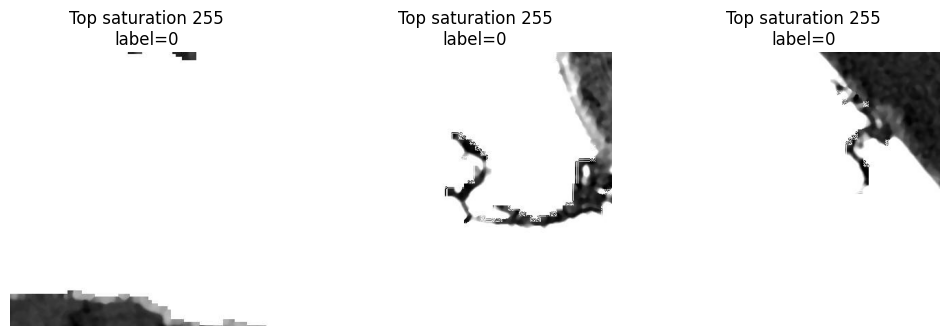

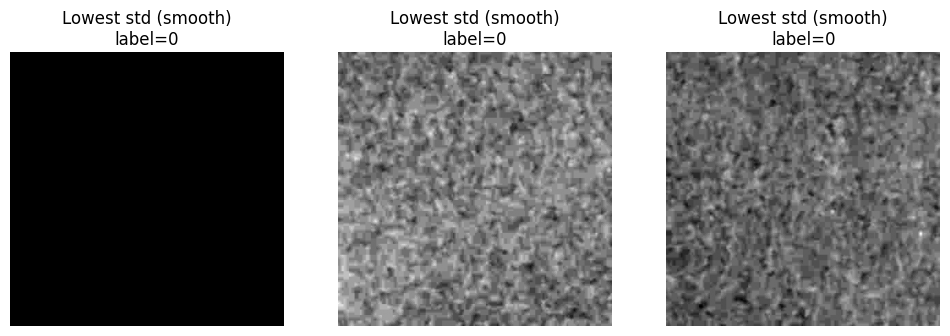

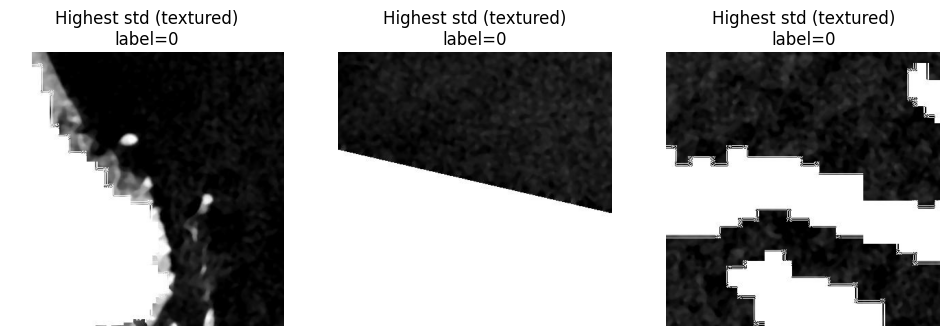

In [19]:
def show_examples(df, title, n=3):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        p = df.iloc[i]["path"]
        label = int(df.iloc[i]["label"])
        img = Image.open(p).convert("L")
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(f"{title}\nlabel={label}")
        plt.axis("off")
    plt.show()

show_examples(top_sat, "Top saturation 255", n=3)
show_examples(low_std, "Lowest std (smooth)", n=3)
show_examples(high_std, "Highest std (textured)", n=3)

La visualisation des images extrêmes confirme les tendances statistiques observées précédemment. Les images présentant une forte saturation (proportion élevée de pixels à 255) correspondent principalement à des zones très claires, souvent associées à des artefacts, des bords côtiers ou des découpes géométriques liées à l’extraction des patches. Ces cas appartiennent quasi exclusivement à la classe non-oil, ce qui suggère qu’une partie du signal discriminant peut provenir d’éléments structurels non directement liés au phénomène physique étudié.

Les images à très faible écart-type apparaissent extrêmement homogènes, parfois presque constantes, ce qui indique la présence possible d’images peu informatives ou issues d’un prétraitement imparfait. À l’inverse, les images à fort écart-type présentent une texture marquée et un contraste élevé, caractéristiques d’une mer plus agitée ou de zones complexes. Ces observations sont cohérentes avec l’hypothèse physique selon laquelle une nappe d’huile lisse la surface marine et réduit la variabilité du signal radar.

Dans l’ensemble, cette analyse met en évidence à la fois un signal physique pertinent (différences de texture) et des artefacts structurels potentiellement biaisants, soulignant l’importance d’une exploration fréquentielle et spatiale plus approfondie.



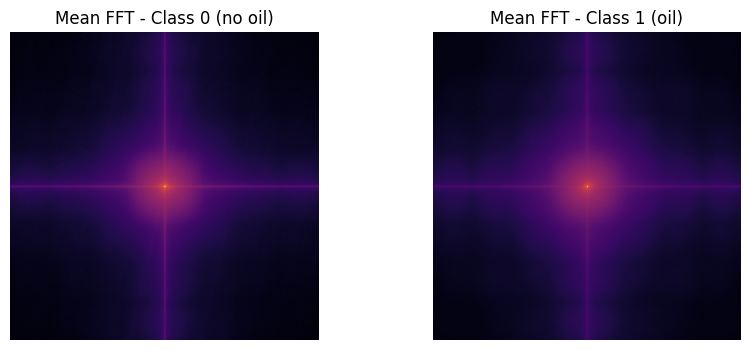

In [20]:
def compute_mean_fft(df, n_samples=200):
    df_sample = df.sample(n=min(n_samples, len(df)), random_state=SEED)

    fft_accumulator = None

    for path in df_sample["path"]:
        img = Image.open(path).convert("L")
        img_array = np.array(img)

        fft = np.fft.fft2(img_array)
        fft_shift = np.fft.fftshift(fft)
        magnitude = np.log1p(np.abs(fft_shift))

        if fft_accumulator is None:
            fft_accumulator = magnitude
        else:
            fft_accumulator += magnitude

    mean_fft = fft_accumulator / len(df_sample)
    return mean_fft


# Séparer classes
df_class0 = stats[stats["label"] == 0]
df_class1 = stats[stats["label"] == 1]

mean_fft_0 = compute_mean_fft(df_class0, n_samples=200)
mean_fft_1 = compute_mean_fft(df_class1, n_samples=200)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mean_fft_0, cmap="inferno")
plt.title("Mean FFT - Class 0 (no oil)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mean_fft_1, cmap="inferno")
plt.title("Mean FFT - Class 1 (oil)")
plt.axis("off")

plt.show()

L’analyse du spectre moyen obtenu par transformée de Fourier met en évidence des différences cohérentes avec les observations spatiales précédentes. Dans les deux classes, l’énergie est majoritairement concentrée au centre du spectre, indiquant la dominance des basses fréquences, ce qui est attendu pour des images naturelles. Cependant, la classe non-oil présente une dispersion plus marquée de l’énergie vers les hautes fréquences, suggérant une plus grande variabilité spatiale et une texture plus complexe.

À l’inverse, la classe oil montre une concentration plus prononcée de l’énergie autour des basses fréquences et une décroissance plus rapide vers la périphérie du spectre. Ce comportement est cohérent avec l’interprétation physique du phénomène : la présence d’une nappe d’huile amortit les petites vagues en surface, réduisant les variations fines du signal radar et produisant une texture plus homogène.

Ainsi, l’analyse fréquentielle confirme les résultats obtenus via les statistiques spatiales (écart-type et texture) et suggère que la différence entre les classes repose en partie sur la distribution de l’énergie haute fréquence. Cette observation renforce l’intérêt de méthodes capables de capturer les motifs texturaux, telles que les approches convolutionnelles.

confirme l’hypothèse physique

montre que la séparation ne repose pas uniquement sur la luminosité

justifie l’usage d’un CNN

Objectif :
Calculer un ratio d’énergie haute fréquence pour chaque image, puis comparer les distributions entre classes.

La transformée de Fourier nous permet d’analyser la distribution fréquentielle des images. Nous avons ensuite dérivé un indicateur mesurant la proportion d’énergie haute fréquence ( c-à-d définir un rayon central = basses fréquences, tout ce qui est en dehors = hautes fréquences + calculer ratio = énergie haute / énergie totale) afin de quantifier objectivement les différences observées entre les classes

In [21]:
def high_frequency_ratio(image_path, radius=30):
    img = Image.open(image_path).convert("L")
    img_array = np.array(img)

    fft = np.fft.fft2(img_array)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.abs(fft_shift)

    h, w = magnitude.shape
    center_y, center_x = h // 2, w // 2

    Y, X = np.ogrid[:h, :w]
    distance = np.sqrt((Y - center_y)**2 + (X - center_x)**2)

    low_freq_mask = distance <= radius
    high_freq_mask = distance > radius

    total_energy = magnitude.sum()
    high_freq_energy = magnitude[high_freq_mask].sum()

    return high_freq_energy / total_energy


# Calcul sur un échantillon
stats_sample = stats.sample(400, random_state=SEED).copy()
stats_sample["hf_ratio"] = stats_sample["path"].apply(high_frequency_ratio)

stats_sample.groupby("label")["hf_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,204.0,0.558195,0.104248,1.418799e-16,0.500054,0.529576,0.598137,0.885688
1,196.0,0.527061,0.091645,4.266801e-01,0.481836,0.502413,0.526147,0.866711


Afin de confirmer quantitativement les observations visuelles issues de l’analyse fréquentielle, nous avons défini un indicateur mesurant la proportion d’énergie située dans les hautes fréquences par rapport à l’énergie totale du spectre. Les résultats montrent que la classe non-oil présente en moyenne un ratio d’énergie haute fréquence plus élevé (≈ 0,56) que la classe oil (≈ 0,53).

Bien que la différence reste modérée, elle est cohérente avec l’interprétation physique du phénomène : une surface océanique agitée génère davantage de variations fines du signal radar, tandis qu’une nappe d’huile amortit les petites vagues, réduisant ainsi la composante haute fréquence du spectre.

Cette observation confirme que la distinction entre les classes ne repose pas uniquement sur l’intensité globale, mais également sur des propriétés texturales et fréquentielles plus subtiles. Elle suggère que des modèles capables de capturer ces structures spatiales complexes, tels que les réseaux convolutionnels, sont particulièrement adaptés à cette tâche.

Boxplot HF ratio par classe

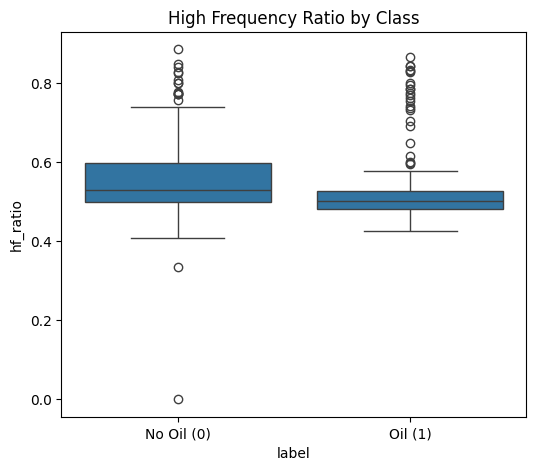

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x="label", y="hf_ratio", data=stats_sample)
plt.title("High Frequency Ratio by Class")
plt.xticks([0,1], ["No Oil (0)", "Oil (1)"])
plt.show()

In [23]:
stats_sample[["std", "hf_ratio"]].corr()

,std,hf_ratio
std,1.000000,0.240054
hf_ratio,0.240054,1.000000


Le boxplot du ratio d’énergie haute fréquence met en évidence une différence systématique entre les deux classes. La médiane de la classe non-oil est légèrement supérieure à celle de la classe oil, indiquant que les images sans nappe d’huile contiennent en moyenne davantage de composantes haute fréquence. La distribution de la classe 0 apparaît également plus étalée, traduisant une variabilité texturale plus importante. Toutefois, un chevauchement significatif entre les deux distributions est observé, montrant que ce descripteur, bien qu’informatif, ne permet pas à lui seul une séparation nette des classes.

L’analyse de corrélation entre l’écart-type spatial et le ratio haute fréquence révèle une corrélation positive modérée (≈ 0,24). Ce résultat confirme qu’une image plus texturée tend à présenter davantage d’énergie haute fréquence. Néanmoins, la corrélation restant limitée, ces deux indicateurs ne sont pas redondants : l’écart-type mesure la dispersion globale des intensités, tandis que le ratio fréquentiel capture plus spécifiquement la structure spectrale du signal.

Dans l’ensemble, ces résultats suggèrent que la distinction entre les classes repose sur des différences texturales réelles mais subtiles. La combinaison de descripteurs spatiaux (mean, std) et fréquentiels (HF ratio) semble donc pertinente pour enrichir la représentation des images et améliorer la capacité de discrimination des modèles.

Conclusion de l’analyse exploratoire

L’analyse exploratoire met en évidence des différences structurelles cohérentes entre les images contenant des nappes d’huile et celles sans huile. Les statistiques globales montrent que les images oil présentent une intensité moyenne plus faible et surtout une variabilité réduite, suggérant une surface plus homogène. Cette observation est confirmée par l’analyse fréquentielle : les images oil concentrent davantage leur énergie dans les basses fréquences, tandis que les images non-oil présentent une proportion légèrement plus élevée d’énergie haute fréquence, traduisant une texture plus marquée.

L’étude des outliers révèle également la présence d’images fortement saturées ou quasi constantes, principalement dans la classe non-oil. Ces cas extrêmes pourraient introduire un biais dans l’apprentissage des modèles en fournissant des signaux discriminants non directement liés au phénomène physique étudié.

Globalement, la séparation entre les classes repose sur des différences texturales réelles mais subtiles. Les distributions se chevauchent significativement, ce qui confirme que le problème n’est pas trivial et nécessite des modèles capables de capturer des structures spatiales complexes. Ces résultats motivent naturellement l’utilisation d’approches convolutionnelles ou l’intégration conjointe de descripteurs spatiaux et fréquentiels dans un modèle prédictif.

Est-ce que mean + std + hf_ratio améliorent réellement la séparation ?
regression logistiae pour test préliminaire


In [ ]:
# Features = mean, std, hf_ratio
features = stats_sample[["mean", "std", "hf_ratio"]]
labels = stats_sample["label"]

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.3, random_state=SEED, stratify=labels
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.52      0.57        61
           1       0.57      0.66      0.61        59

    accuracy                           0.59       120
   macro avg       0.59      0.59      0.59       120
weighted avg       0.59      0.59      0.59       120



Afin d’évaluer l’apport réel des descripteurs extraits lors de l’analyse exploratoire, une régression logistique a été entraînée en utilisant trois variables : la moyenne d’intensité, l’écart-type spatial et le ratio d’énergie haute fréquence. Les performances obtenues (accuracy ≈ 59 %) montrent que ces caractéristiques, bien qu’informatives, ne permettent pas une séparation robuste des classes.

Ce résultat est cohérent avec les observations précédentes : les différences entre les classes existent mais restent subtiles et fortement chevauchées. Les statistiques globales capturent une partie du signal (différences de texture et de contenu fréquentiel), mais elles ne suffisent pas à modéliser la complexité spatiale des images SAR.

In [26]:
!ls -lah data

total 16K
drwxr-xr-x 4 root root 4.0K Feb 28 13:00 .
drwxr-xr-x 6 root root 4.0K Feb 28 13:00 ..
drwxr-xr-x 5 root root 4.0K Feb 28 13:00 data
drwxr-xr-x 2 root root 4.0K Feb 28 13:00 metadata


In [27]:
!grep -n "organize\|split\|train/\|val/\|test/\|TRAIN_DIR\|VAL_DIR\|TEST_DIR" -n model_training.ipynb | head -n 40

32:    "from utils import (plot_class_distribution, show_class_distribution, create_train_test_val_split , \n",
55:    "TEST_DIR = ROOT_DIR / 'test/'\n",
56:    "TRAIN_DIR = ROOT_DIR / 'train/'\n",
57:    "VAL_DIR = ROOT_DIR / 'val/'\n",
6703:      "Dataset split completed. Organized data saved to: data\n"
6708:    "create_train_test_val_split(\n",
6731:      "   1. data/train/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_EppU8Z5MCiREy7AA_GBR_cls_0.jpg\n",
6732:      "   2. data/train/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg\n",
6734:      "   1. data/train/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_l7912hDB89MxQhzN_GBR_cls_0.jpg\n",
6735:      "   2. data/train/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg\n",
6737:      "   1. data/train/S1SAR_UnBalanced_400by400_Class_0/1995_600_7000_img_P81b6DktZJCbmOmO_SIN_cls_0.jpg\n",
6738:      "   2. data/train/S1SAR_UnBalanced_400by400_Class_0/

In [28]:
!grep -n "def create_train_test_val_split" -n utils.py -A 80

207:def create_train_test_val_split(data_dir,output_dir="./data/organized", train_ratio=0.7,val_ratio=0.15,test_ratio=0.15,seed=42, allowed_classes=None): 
208-
209-    """
210-    Create train, val, test splits from a dataset organized as:
211-    data_dir/
212-        class0/
213-            img1.jpg
214-            img2.jpg
215-        class1/
216-            img3.jpg
217-            img4.jpg
218-    """
219-
220-    random.seed(seed)
221-
222-    data_dir = Path(data_dir)
223-    output_dir = Path(output_dir)
224-
225-    assert train_ratio + val_ratio + test_ratio == 1.0 # Ensure ratios sum to 1
226-
227-    dataset = get_files_by_class(data_dir)
228-
229-    for class_name, images in dataset.items(): 
230-        if allowed_classes is not None and class_name not in allowed_classes:
231-            print(f"Skipping class: {class_name} as it's not in allowed_classes")
232-            continue
233-
234-        random.shuffle(images)
235-
236-        n = len(images)
237-        train

In [ ]:
ROOT_DIR = Path("./data/")
DATA_DIR = ROOT_DIR / "data"
SEED = 42

create_train_test_val_split(
    data_dir=DATA_DIR,
    output_dir=ROOT_DIR,      # => ./data/train, ./data/val, ./data/test
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=SEED
)

!ls -lah data

Dataset split completed. Organized data saved to: data
total 28K
drwxr-xr-x 7 root root 4.0K Feb 28 13:19 .
drwxr-xr-x 6 root root 4.0K Feb 28 13:00 ..
drwxr-xr-x 5 root root 4.0K Feb 28 13:00 data
drwxr-xr-x 2 root root 4.0K Feb 28 13:00 metadata
drwxr-xr-x 5 root root 4.0K Feb 28 13:19 test
drwxr-xr-x 5 root root 4.0K Feb 28 13:19 train
drwxr-xr-x 5 root root 4.0K Feb 28 13:19 val


In [ ]:


ROOT_DIR = Path("./data/")
DATA_DIR = ROOT_DIR / "data"
SEED = 42

# Supprimer anciens dossiers train/val/test
for folder in ["train", "val", "test"]:
    shutil.rmtree(ROOT_DIR / folder, ignore_errors=True)

create_train_test_val_split(
    data_dir=DATA_DIR,
    output_dir=ROOT_DIR,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=SEED,
    allowed_classes=[
        "S1SAR_UnBalanced_400by400_Class_0",
        "S1SAR_UnBalanced_400by400_Class_1"
    ]
)

!ls data

Skipping class: Samples as it's not in allowed_classes
Dataset split completed. Organized data saved to: data
data  metadata	test  train  val


In [ ]:


ROOT_DIR = Path("./data/")
TRAIN_DIR = ROOT_DIR / "train"
VAL_DIR = ROOT_DIR / "val"
TEST_DIR = ROOT_DIR / "test"
SEED = 42

BATCH_SIZE = 16
IMG_SIZE = (224, 224)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

print("Class names:", train_ds.class_names)

Found 3940 files belonging to 2 classes.
Found 845 files belonging to 2 classes.
Found 845 files belonging to 2 classes.
Class names: ['S1SAR_UnBalanced_400by400_Class_0', 'S1SAR_UnBalanced_400by400_Class_1']


In [34]:
AUTOTUNE = tf.data.AUTOTUNE

# Normalisation [0,1]
def normalize(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, y

train_ds_p = train_ds.map(normalize, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds_p   = val_ds.map(normalize,   num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds_p  = test_ds.map(normalize,  num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

print("OK preprocessing")

OK preprocessing


In [ ]:

LEARNING_RATE = 1e-3

model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 1)),

    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,234,689 (12.34 MB)

 Trainable params: 3,234,689 (12.34 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
NUM_EPOCHS = 10

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

history = model.fit(
    train_ds_p,
    validation_data=val_ds_p,
    epochs=NUM_EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 190s 767ms/step - accuracy: 0.6892 - loss: 0.5718 - val_accuracy: 0.7053 - val_loss: 0.5928
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 200s 760ms/step - accuracy: 0.7021 - loss: 0.5572 - val_accuracy: 0.7053 - val_loss: 0.6330
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 185s 749ms/step - accuracy: 0.7158 - loss: 0.5500 - val_accuracy: 0.6852 - val_loss: 0.5885
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 184s 743ms/step - accuracy: 0.7276 - loss: 0.5421 - val_accuracy: 0.6994 - val_loss: 0.6366
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 206s 761ms/step - accuracy: 0.7480 - loss: 0.5184 - val_accuracy: 0.7207 - val_loss: 0.6530
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 193s 780ms/step - accuracy: 0.7522 - loss: 0.5131 - val_accuracy: 0.7160 - val_loss: 0.6993


In [ ]:

# Probabilités sur test
y_prob = model.predict(test_ds_p).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Vrais labels
y_true = np.concatenate([y.numpy() for _, y in test_ds_p], axis=0)

print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=3))

53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 218ms/step
Confusion matrix:
 [[481  78]
 [159 127]]

Classification report:
               precision    recall  f1-score   support

           0      0.752     0.860     0.802       559
           1      0.620     0.444     0.517       286

    accuracy                          0.720       845
   macro avg      0.686     0.652     0.660       845
weighted avg      0.707     0.720     0.706       845



Le modèle convolutionnel de base atteint une accuracy globale d’environ 72 % sur le jeu de test, ce qui constitue une amélioration significative par rapport à la régression logistique basée sur des descripteurs globaux. Cependant, l’analyse détaillée par classe révèle une performance asymétrique : la classe majoritaire (non-oil) est bien détectée (recall ≈ 0,86), tandis que la classe oil présente un recall plus faible (≈ 0,44) et un F1-score modéré (≈ 0,52).

La matrice de confusion montre que le modèle produit un nombre important de faux négatifs (159 nappes d’huile non détectées), ce qui est particulièrement critique dans un contexte environnemental où la détection des pollutions marines est prioritaire. Ce comportement s’explique en partie par le déséquilibre du dataset, qui incite le modèle à privilégier la classe majoritaire afin d’optimiser l’accuracy globale.

Calcul automatique des class weights

In [ ]:

# Extraire labels du train dataset
y_train = np.concatenate([y.numpy() for _, y in train_ds], axis=0)

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("Classes:", classes)
print("Class weights:", class_weight)

Classes: [0 1]
Class weights: {0: 0.7556578442654392, 1: 1.4778694673668418}


la classe 1 est plus pondérée (~1.48), donc le modèle sera pénalisé davantage quand il rate de l’huile. Il faut réentraîner le même modèle avec class_weight

In [ ]:
# Recréer le même modèle (reset weights)

LEARNING_RATE = 1e-3
NUM_EPOCHS = 10

model_w = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 1)),
    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model_w.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

history_w = model_w.fit(
    train_ds_p,
    validation_data=val_ds_p,
    epochs=NUM_EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 196s 784ms/step - accuracy: 0.6022 - loss: 0.6851 - val_accuracy: 0.4331 - val_loss: 0.6699
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 189s 766ms/step - accuracy: 0.4878 - loss: 0.6473 - val_accuracy: 0.4556 - val_loss: 0.6727
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 199s 754ms/step - accuracy: 0.4956 - loss: 0.6231 - val_accuracy: 0.6473 - val_loss: 0.6452
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 202s 755ms/step - accuracy: 0.6419 - loss: 0.5951 - val_accuracy: 0.6225 - val_loss: 0.6749
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 206s 770ms/step - accuracy: 0.6582 - loss: 0.5697 - val_accuracy: 0.6154 - val_loss: 0.7192
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 198s 756ms/step - accuracy: 0.6969 - loss: 0.5521 - val_accuracy: 0.6426 - val_loss: 0.7036


In [ ]:

y_prob_w = model_w.predict(test_ds_p).ravel()
y_pred_w = (y_prob_w >= 0.5).astype(int)
y_true = np.concatenate([y.numpy() for _, y in test_ds_p], axis=0)

print("Confusion matrix:\n", confusion_matrix(y_true, y_pred_w))
print("\nClassification report:\n", classification_report(y_true, y_pred_w, digits=3))

53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 321ms/step
Confusion matrix:
 [[376 183]
 [ 98 188]]

Classification report:
               precision    recall  f1-score   support

           0      0.793     0.673     0.728       559
           1      0.507     0.657     0.572       286

    accuracy                          0.667       845
   macro avg      0.650     0.665     0.650       845
weighted avg      0.696     0.667     0.675       845



L’introduction de pondérations de classes modifie significativement le comportement du modèle. Alors que le CNN baseline favorisait la classe majoritaire (non-oil), l’utilisation de class_weight augmente sensiblement le recall de la classe oil (≈ 0,66 contre ≈ 0,44 précédemment). Cette amélioration traduit une meilleure capacité à détecter les nappes d’huile, réduisant le nombre de faux négatifs. En contrepartie, l’accuracy globale diminue (≈ 0,67) et le nombre de faux positifs augmente, illustrant le compromis classique entre sensibilité et spécificité.

In [ ]:

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob_w >= t).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred_t, average=None
    )
    results.append((t, precision[1], recall[1], f1[1]))

print("Threshold | Precision_1 | Recall_1 | F1_1")
for r in results:
    print(f"{r[0]:.2f}       | {r[1]:.3f}       | {r[2]:.3f}     | {r[3]:.3f}")

Threshold | Precision_1 | Recall_1 | F1_1
0.10       | 0.368       | 0.986     | 0.536
0.15       | 0.371       | 0.986     | 0.539
0.20       | 0.372       | 0.983     | 0.540
0.25       | 0.373       | 0.979     | 0.541
0.30       | 0.382       | 0.972     | 0.548
0.35       | 0.396       | 0.962     | 0.561
0.40       | 0.405       | 0.874     | 0.554
0.45       | 0.431       | 0.766     | 0.552
0.50       | 0.507       | 0.657     | 0.572
0.55       | 0.532       | 0.573     | 0.552
0.60       | 0.557       | 0.479     | 0.515
0.65       | 0.632       | 0.276     | 0.384
0.70       | 0.667       | 0.014     | 0.027
0.75       | 1.000       | 0.010     | 0.021
0.80       | 1.000       | 0.007     | 0.014
0.85       | 0.000       | 0.000     | 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Le modèle présente un compromis typique entre précision et rappel.
Les seuils faibles maximisent la sensibilité mais génèrent un nombre élevé de faux positifs.
Le seuil de 0.5 offre le meilleur équilibre F1, ce qui indique que la calibration probabiliste du modèle est relativement stable après pondération des classes.

Dans un contexte opérationnel, le choix du seuil dépendra de la tolérance aux fausses alertes.
Si l’objectif est la surveillance environnementale préventive, un seuil autour de 0.35–0.40 pourrait être envisagé.
Si l’objectif est la fiabilité des alertes, le seuil 0.5 reste approprié.
